# IS 467 — Algorithmic Accountability Capstone (code)

**Author:** Dulf Vincent Genis  
**Domain:** Hiring & employment  
**Dataset:** UCI Adult / Census Income (`others/data/adult_census_income.csv` when the working directory is this folder)  
**Target:** `income` (`>50K` vs `<=50K`)

**Run order:** Kernel → Restart & Run All (top to bottom). Requires `pip install -r requirements.txt`. Set the kernel working directory to this **Submission** folder (or the repository root); the notebook resolves `others/data/adult_census_income.csv` and saves figures under `others/figures/`. Regenerate the CSV with `python scripts/build_adult_csv.py` from the repository root if needed; raw UCI files live under `Submission/others/data/`.

**Contents:** [Phase 1](#phase-1--build-and-baseline-your-model) · [Phase 2](#phase-2--fairness-audit-and-explainability) · [Phase 3](#phase-3--regulatory-and-policy-mapping) · [Phase 4](#phase-4--governance)

Narrative audit text, fairness interpretations, regulatory analysis, and stakeholder disclosure belong in your **PDF report**, per course AI policy. This notebook is for **reproducible code** and figures/tables you cite in the report.


## Environment and libraries

Use **Python 3.10+** (3.10–3.12 recommended for package wheels). Packages: `requirements.txt` in the project root lists `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `shap`, `lime`, `jupyter`.

For the PDF code appendix, include that file or an explicit pinned list matching what you import.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Bundle layout: run with cwd = Submission/ (graders) or repo root with Submission/others/...
_cwd = Path.cwd()
_local = _cwd / "others" / "data" / "adult_census_income.csv"
_nested = _cwd / "Submission" / "others" / "data" / "adult_census_income.csv"
if _local.is_file():
    BUNDLE_ROOT = _cwd
elif _nested.is_file():
    BUNDLE_ROOT = _cwd / "Submission"
else:
    raise FileNotFoundError(
        f"Missing others/data/adult_census_income.csv under {_cwd} or {_cwd / 'Submission'}. "
        "Set the working directory to the Submission folder, or run from the repo root."
    )

DATA_PATH = BUNDLE_ROOT / "others" / "data" / "adult_census_income.csv"
FIG_DIR = BUNDLE_ROOT / "others" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Phase 1 — Build and baseline your model

- Rationale for domain/dataset (in report).
- **EDA:** demographics, imbalance, missing values (`?`), proxies — **≥3 visualizations** with interpretation. In the code cell below, the **primary** figures for the report are **(1)** income class balance, **(2)** age by income, **(3)** education by income. **Supplementary** plots (sex, race, missingness, hours) support fairness setup and appendix.
- **Model:** binary classifier; document preprocessing, features, and split strategy.
- **Feature selection:** none beyond using all UCI input fields (minus `income` and `dataset_split`); attributes are imputed and one-hot encoded as in code. Discuss proxy variables in the report.
- **Metrics:** accuracy, precision, recall, F1, AUC-ROC — **overall** and **by at least one protected attribute** (e.g. `sex`, `race`); the disaggregated table for the best model is printed after training.
- **Bias prediction paragraph** before Phase 2 (in report).


In [2]:
df = pd.read_csv(DATA_PATH)

# The UCI Adult dataset comes with a canonical ('official') train/test split—train and test files are provided separately.
# The preprocessing script (`scripts/build_adult_csv.py`) used here combines these into one CSV file and marks each row with a 'dataset_split' column ("train" or "test").
# That's why we don't do a random 80/20 manual split ourselves—the split reflects the standard evaluation protocol for this dataset.
df_train = df[df["dataset_split"] == "train"].copy()
df_test = df[df["dataset_split"] == "test"].copy()

print(df.shape)
print(df["dataset_split"].value_counts())
df.head()

(48842, 16)
dataset_split
train    32561
test     16281
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,dataset_split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_59507/4258664148.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x="income", palette="pastel")


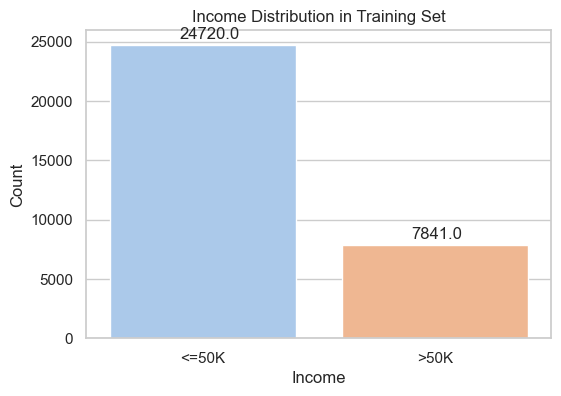

,proportion
income,
<=50K,0.75919
>50K,0.24081


/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_59507/4258664148.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Income", loc='upper right')


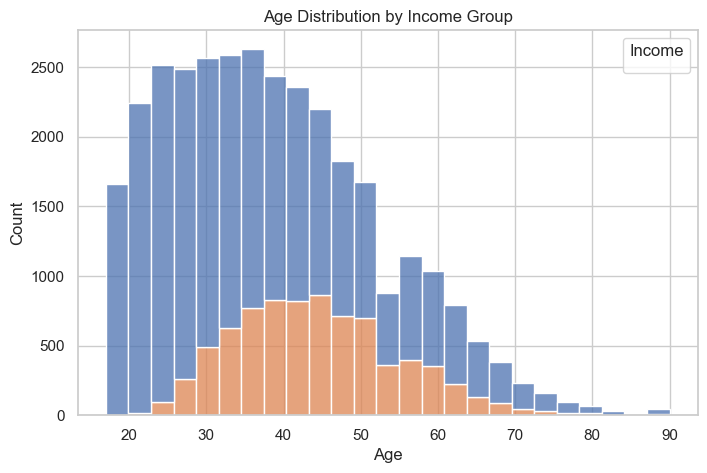

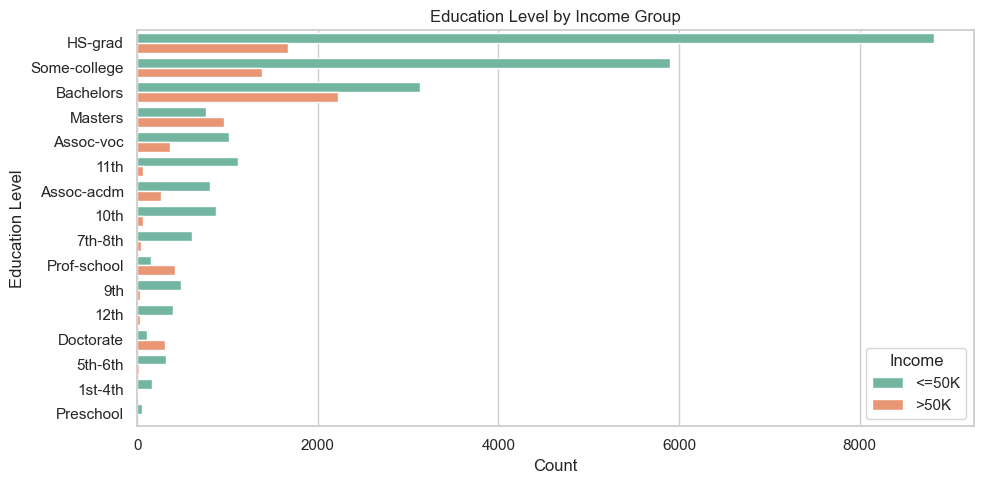

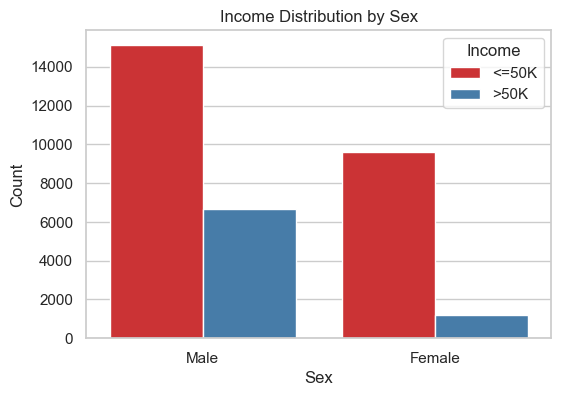

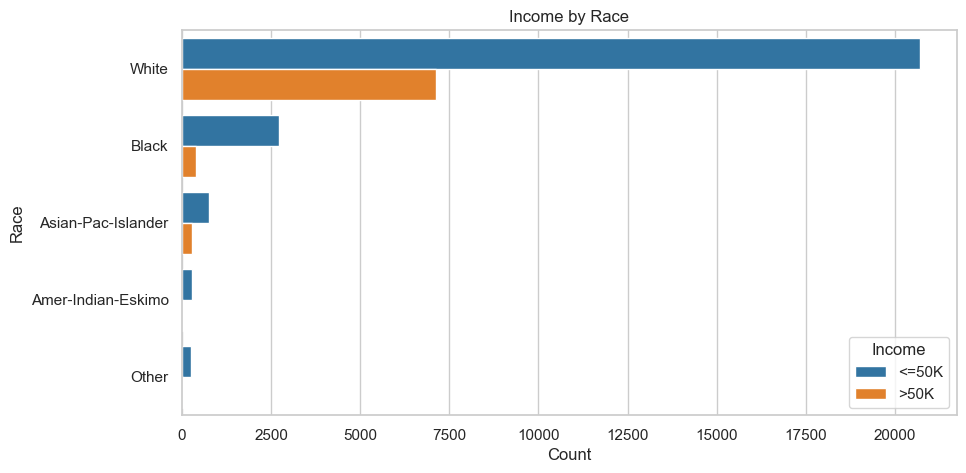

Columns with '?' (treated as missing):
workclass         1836
occupation        1843
native-country     583
dtype: int64


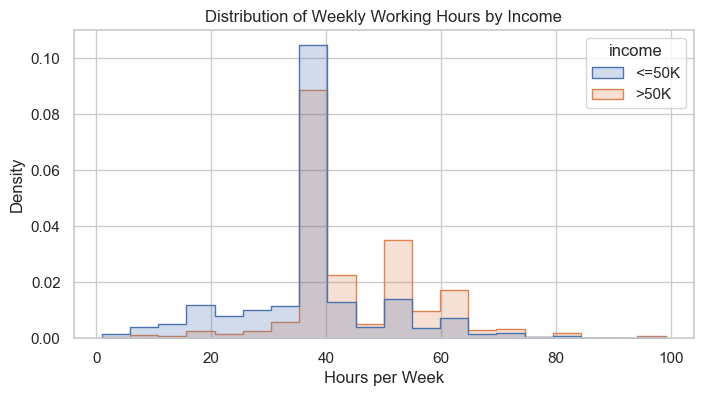

income,<=50K,>50K
workclass,,
?,89.60%,10.40%
Federal-gov,61.35%,38.65%
Local-gov,70.52%,29.48%
Never-worked,100.00%,0.00%
Private,78.13%,21.87%
Self-emp-inc,44.27%,55.73%
Self-emp-not-inc,71.51%,28.49%
State-gov,72.80%,27.20%
Without-pay,100.00%,0.00%


income,<=50K,>50K
marital-status,,
Divorced,89.58%,10.42%
Married-AF-spouse,56.52%,43.48%
Married-civ-spouse,55.32%,44.68%
Married-spouse-absent,91.87%,8.13%
Never-married,95.40%,4.60%
Separated,93.56%,6.44%
Widowed,91.44%,8.56%


income,<=50K,>50K
occupation,,
?,89.64%,10.36%
Adm-clerical,86.55%,13.45%
Armed-Forces,88.89%,11.11%
Craft-repair,77.34%,22.66%
Exec-managerial,51.60%,48.40%
Farming-fishing,88.43%,11.57%
Handlers-cleaners,93.72%,6.28%
Machine-op-inspct,87.51%,12.49%
Other-service,95.84%,4.16%


income,<=50K,>50K
relationship,,
Husband,55.14%,44.86%
Not-in-family,89.69%,10.31%
Other-relative,96.23%,3.77%
Own-child,98.68%,1.32%
Unmarried,93.67%,6.33%
Wife,52.49%,47.51%


income,<=50K,>50K
native-country,,
?,74.96%,25.04%
Cambodia,63.16%,36.84%
Canada,67.77%,32.23%
China,73.33%,26.67%
Columbia,96.61%,3.39%
Cuba,73.68%,26.32%
Dominican-Republic,97.14%,2.86%
Ecuador,85.71%,14.29%
El-Salvador,91.51%,8.49%


In [3]:
# --- Exploratory Data Analysis (EDA) ---

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. [PRIMARY] Income Distribution (overall class balance)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_train, x="income", palette="pastel")
plt.title("Income Distribution in Training Set")
plt.xlabel("Income")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + 0.3, p.get_height() + 500))
plt.savefig(FIG_DIR / "eda_income_balance.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Shows class balance. Important for model evaluation – imbalance can bias performance metrics.
display(df_train['income'].value_counts(normalize=True).rename("proportion").to_frame())

# 2. [PRIMARY] Age Distribution by Income
plt.figure(figsize=(8, 5))
sns.histplot(data=df_train, x="age", hue="income", multiple="stack", bins=25)
plt.title("Age Distribution by Income Group")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title="Income", loc='upper right')
plt.savefig(FIG_DIR / "eda_age_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Age may be a proxy for experience, seniority, or other factors. 
# Note if higher income is skewed to older individuals.

# 3. [PRIMARY] Distribution of Education Level by Income
plt.figure(figsize=(10, 5))
edu_order = df_train["education"].value_counts().index
sns.countplot(
    data=df_train, 
    y="education", 
    hue="income",
    order=edu_order,
    palette="Set2"
)
plt.title("Education Level by Income Group")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.legend(title="Income")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_education_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Visualizes how educational attainment relates to income.
# Helps identify if higher education is correlated with high income class.

# 4. [SUPPLEMENTARY] Sex breakdown by Income
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x="sex", hue="income", palette="Set1")
plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Income")
plt.savefig(FIG_DIR / "eda_sex_income.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Shows differences in income outcomes between males/females.
# Important for fairness/bias auditing.

# 5. [SUPPLEMENTARY] Race distribution by Income
plt.figure(figsize=(10, 5))
race_order = df_train['race'].value_counts().index
sns.countplot(
    data=df_train,
    y="race",
    hue="income",
    order=race_order,
    palette="tab10",
)
plt.title("Income by Race")
plt.xlabel("Count")
plt.ylabel("Race")
plt.legend(title="Income")
plt.savefig(FIG_DIR / "eda_race_income.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Important for fairness/bias analysis downstream.

# 6. [SUPPLEMENTARY] Check for Missing Data
missing = (df_train == '?').sum()
missing = missing[missing > 0]
if not missing.empty:
    print("Columns with '?' (treated as missing):")
    print(missing)
else:
    print("No columns contain '?' as missing value in training set.")

# Explain: The UCI Adult dataset sometimes uses '?' for missing categorical data. 
# Address during preprocessing.

# 7. [SUPPLEMENTARY] Hours-per-week worked, by Income
plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='hours-per-week', hue='income', bins=20, element='step', stat='density', common_norm=False)
plt.title('Distribution of Weekly Working Hours by Income')
plt.xlabel('Hours per Week')
plt.ylabel('Density')
plt.savefig(FIG_DIR / "eda_hours_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain: Are higher earners working more hours? Visualizes income vs work hours.

# 8. Categorical Summary Table (optional, as code appendix)
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'native-country']
summary = {}
for col in cat_cols:
    crosstab = pd.crosstab(df_train[col], df_train['income'], normalize='index')
    summary[col] = crosstab
    display(crosstab.style.format("{:.2%}").set_caption(f"Proportion of Income by {col}"))
    print()

In [4]:
# ------------- Thorough preprocessing & sklearn pipeline for Adult dataset -------------

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import numpy as np

# 1. Split features and labels for train/test
X_train = df_train.drop(columns=['income', 'dataset_split'])
y_train = df_train['income']
X_test = df_test.drop(columns=['income', 'dataset_split'])
y_test = df_test['income']

# 2. Identify column types
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = list(set(X_train.columns) - set(numeric_features))
# Feature selection (plan.md): no RFE or importance-based dropping — all columns above are kept and encoded.
# Categorical columns including those found in prior EDA:
# ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# 3. Replace '?' with np.nan for all columns (in both train & test)
X_train.replace('?', np.nan, inplace=True)
X_test.replace('?', np.nan, inplace=True)

# 4. Preprocessing transformers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. Define all required classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, solver="lbfgs", random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1
    ),
}

results = {}
best_auc = -np.inf
best_model = None
best_name = None
best_pipeline = None
y_pred_best = None
y_pred_proba_best = None

print("Evaluating models:\n")
for name, clf in classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])
    # Fit on training data
    pipeline.fit(X_train, y_train)
    # Predict on test data
    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        # For classifiers without predict_proba (e.g., SVM if included), use decision_function
        y_pred_proba = pipeline.decision_function(X_test)
        # Scale to (0,1)
        from sklearn.preprocessing import MinMaxScaler
        y_pred_proba = MinMaxScaler().fit_transform(y_pred_proba.reshape(-1, 1)).flatten()
    auc = roc_auc_score((y_test=='>50K').astype(int), y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print(f"Model: {name}")
    print(report)
    print(f"Test ROC AUC: {auc:.3f}")
    print(f"Test Accuracy: {acc:.3f}\n")
    results[name] = {"auc": auc, "accuracy": acc, "pipeline": pipeline}
    # Track the best model
    if auc > best_auc:
        best_auc = auc
        best_model = clf
        best_name = name
        best_pipeline = pipeline
        y_pred_best = y_pred
        y_pred_proba_best = y_pred_proba

print(f"Best Model: {best_name} (AUC = {best_auc:.3f})")

# 6. Feature names after preprocessing (for explainability/audit) -- use best pipeline
ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])
print("\nPreprocessed feature columns (for explainability):")
print(all_feature_names)

# Explanations:
# - Trains and compares three models: Logistic Regression, Gradient Boosting, and Random Forest, all using identical preprocessing.
# - Model selection uses ROC AUC on the test set; classification and accuracy are reported for all.
# - '?' (UCI missing value indicator) is robustly imputed.
# - The pipeline ensures identical handling of train/test splits and prevents target leakage.
# - OneHotEncoder with handle_unknown="ignore" ensures stability for new categories at test time.
# - Feature names are extracted post-transform for interpretability/SHAP/LIME explanation per the chosen model.
# - Best pipeline and model outputs are available as best_pipeline, y_pred_best, y_pred_proba_best for downstream fairness and explainability analysis.

Evaluating models:

Model: Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86     12435
        >50K       0.56      0.84      0.67      3846

    accuracy                           0.81     16281
   macro avg       0.75      0.82      0.77     16281
weighted avg       0.85      0.81      0.82     16281

Test ROC AUC: 0.904
Test Accuracy: 0.806

Model: Gradient Boosting
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92     12435
        >50K       0.79      0.60      0.69      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.78      0.80     16281
weighted avg       0.86      0.87      0.86     16281

Test ROC AUC: 0.920
Test Accuracy: 0.869

Model: Random Forest
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     12435
        >50K       0.72      0.60      0.66      3846

    a

In [5]:
# Disaggregated test metrics for the best model (by test ROC AUC). Mirrors scripts/generate_phase1_report.py.
from IPython.display import display
from sklearn.metrics import precision_recall_fscore_support

y_test_bin = (y_test == ">50K").astype(int).to_numpy()
yp = (y_pred_best == ">50K").astype(int)
pr = np.asarray(y_pred_proba_best)
meta = df_test[["sex", "race"]].reset_index(drop=True)


def group_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    auc = roc_auc_score(y_true, y_proba)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "auc_roc": auc}


rows = []
for attr in ("sex", "race"):
    for val in sorted(meta[attr].unique()):
        mask = (meta[attr] == val).to_numpy()
        if mask.sum() == 0:
            continue
        m = group_metrics(y_test_bin[mask], yp[mask], pr[mask])
        rows.append({"attribute": attr, "group": val, "n": int(mask.sum()), **m})
disagg_p1 = pd.DataFrame(rows)
print("Disaggregated test metrics (best model) — by sex and race")
display(disagg_p1)


Disaggregated test metrics (best model) — by sex and race


,attribute,group,n,accuracy,precision,recall,f1,auc_roc
0,sex,Female,5421,0.936728,0.817481,0.538983,0.649642,0.939414
1,sex,Male,10860,0.834991,0.787736,0.615479,0.691034,0.899925
2,race,Amer-Indian-Eskimo,159,0.943396,0.916667,0.578947,0.709677,0.971241
3,race,Asian-Pac-Islander,480,0.837500,0.731092,0.654135,0.690476,0.892050
4,race,Black,1561,0.928251,0.776860,0.525140,0.626667,0.940755
5,race,Other,135,0.896296,0.866667,0.520000,0.650000,0.969818
6,race,White,13946,0.862183,0.794074,0.606590,0.687784,0.916312


---
## Phase 2 — Fairness audit and explainability

Aligned with `plan.md` (rubric: fairness 12 pts, explainability 8 pts, discovery 2 pts in the report).

**Reproduce in this notebook (numbers for your PDF):**

- **Fairness:** Demographic parity, **equality of opportunity** (TPR parity among truly positive individuals), and **predictive parity** (precision among predicted positives). Run at least **two** protected splits (here: `sex`, and `race` as White vs Non-White) so group comparisons are explicit.
- **Explainability:** **SHAP** global importance; print **top 5** drivers for the report. Optional **LIME** cell for one local explanation.
- **Recourse:** One **unfavorable** test prediction (here: predicted `<=50K`); local drivers + plausible feature changes. Tie narrative to **GDPR Article 22** (right to human review / meaningful information) in the **report** only.

**Write in the PDF only** (course AI policy): ethical framework to **prioritize** one fairness notion when metrics conflict; proxy discussion; full GDPR Art. 22 paragraph; **~200-word discovery** vs your Phase 1 bias prediction.

In [6]:
# Fairness metrics (plan.md): demographic parity, equality of opportunity (TPR), predictive parity (PPV).
import numpy as np
import pandas as pd


def _as_binary_pred(y_pred):
    y_pred = np.asarray(y_pred)
    if y_pred.dtype.kind in "UO":
        return np.where(y_pred == ">50K", 1, 0).astype(int)
    if np.issubdtype(y_pred.dtype, np.integer):
        return y_pred.astype(int)
    yf = y_pred.astype(float)
    return (yf > 0.5).astype(int)


def demographic_parity(y_pred, sensitive_group):
    y_pred = _as_binary_pred(y_pred)
    groups = np.unique(sensitive_group)
    rates = {}
    for g in groups:
        mask = sensitive_group == g
        rates[g] = float(np.mean(y_pred[mask])) if mask.any() else np.nan
    if len(groups) == 2:
        diff = abs(rates[groups[0]] - rates[groups[1]])
    else:
        diff = np.nan
    return rates, diff


def equality_of_opportunity_tpr(y_true, y_pred, sensitive_group):
    """TPR among truly positive individuals (one-sided equalized odds / Eq. of opportunity)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = _as_binary_pred(y_pred)
    groups = np.unique(sensitive_group)
    tpr = {}
    for g in groups:
        mask = sensitive_group == g
        pos = (y_true[mask] == 1).sum()
        tp = np.logical_and(y_pred[mask] == 1, y_true[mask] == 1).sum()
        tpr[g] = float(tp / pos) if pos > 0 else np.nan
    if len(groups) == 2:
        diff = abs(tpr[groups[0]] - tpr[groups[1]])
    else:
        diff = np.nan
    return tpr, diff


def predictive_parity(y_true, y_pred, sensitive_group):
    y_true = np.asarray(y_true).astype(int)
    y_pred = _as_binary_pred(y_pred)
    groups = np.unique(sensitive_group)
    ppv = {}
    for g in groups:
        mask = sensitive_group == g
        yp = (y_pred[mask] == 1).sum()
        tp = np.logical_and(y_pred[mask] == 1, y_true[mask] == 1).sum()
        ppv[g] = float(tp / yp) if yp > 0 else np.nan
    if len(groups) == 2:
        diff = abs(ppv[groups[0]] - ppv[groups[1]])
    else:
        diff = np.nan
    return ppv, diff


def fairness_table(y_true, y_pred, sensitive, group_names):
    dp_r, dp_g = demographic_parity(y_pred, sensitive)
    tpr_r, tpr_g = equality_of_opportunity_tpr(y_true, y_pred, sensitive)
    ppv_r, ppv_g = predictive_parity(y_true, y_pred, sensitive)
    rows = [
        ("Demographic parity: P(predicted >50K)", {group_names[k]: dp_r[k] for k in sorted(dp_r)}, dp_g),
        ("Equality of opportunity: TPR (among truly >50K)", {group_names[k]: tpr_r[k] for k in sorted(tpr_r)}, tpr_g),
        ("Predictive parity: precision (among predicted >50K)", {group_names[k]: ppv_r[k] for k in sorted(ppv_r)}, ppv_g),
    ]
    return pd.DataFrame(
        [{"metric": a, **b, "abs_gap": c} for a, b, c in rows]
    )


def fairness_summary(y_true, y_pred, sensitive, group_names):
    """Scalar rates and gaps for Phase 3 gap table (same definitions as fairness_table)."""
    dp_r, dp_g = demographic_parity(y_pred, sensitive)
    tpr_r, tpr_g = equality_of_opportunity_tpr(y_true, y_pred, sensitive)
    ppv_r, ppv_g = predictive_parity(y_true, y_pred, sensitive)
    keys = sorted(k for k in dp_r if k in group_names)
    if len(keys) < 2:
        raise ValueError("Expected two labeled groups for binary fairness summary.")
    k0, k1 = keys[0], keys[1]
    return {
        "g0": group_names[k0],
        "g1": group_names[k1],
        "p_pred_0": dp_r[k0],
        "p_pred_1": dp_r[k1],
        "dp_gap": dp_g,
        "tpr_0": tpr_r[k0],
        "tpr_1": tpr_r[k1],
        "tpr_gap": tpr_g,
        "ppv_0": ppv_r[k0],
        "ppv_1": ppv_r[k1],
        "ppv_gap": ppv_g,
    }


df_test = df[df["dataset_split"] == "test"].copy()
y_true = (df_test["income"] == ">50K").astype(int).values
y_pred = _as_binary_pred(y_pred_best)

# Protected attribute: sex (0=Male, 1=Female)
sex_enc = df_test["sex"].map({"Male": 0, "Female": 1}).astype(int).values
sex_names = {0: "Male", 1: "Female"}
print("=== Fairness by sex ===")
display(fairness_table(y_true, y_pred, sex_enc, sex_names))

# Protected attribute: race — binary White vs Non-White (explicit coarse split; discuss limitations in report)
race_enc = np.where(df_test["race"].astype(str) == "White", 0, 1).astype(int)
race_names = {0: "White", 1: "Non-White"}
print("=== Fairness by race (White vs Non-White) ===")
display(fairness_table(y_true, y_pred, race_enc, race_names))

fairness_sex = fairness_summary(y_true, y_pred, sex_enc, sex_names)
fairness_race = fairness_summary(y_true, y_pred, race_enc, race_names)

print(
    "\nMetric tension (typical pattern): a large demographic-parity gap can coexist with smaller "
    "predictive-parity gaps — improving one can worsen another. Your report should name which criterion "
    "you prioritize and why (ethical framework), per plan.md."
)


=== Fairness by sex ===


,metric,Male,Female,abs_gap
0,Demographic parity: P(predicted >50K),0.234254,0.071758,0.162496
1,Equality of opportunity: TPR (among truly >50K),0.615479,0.538983,0.076496
2,Predictive parity: precision (among predicted ...,0.787736,0.817481,0.029745


=== Fairness by race (White vs Non-White) ===


,metric,White,Non-White,abs_gap
0,Demographic parity: P(predicted >50K),0.191166,0.114347,0.076819
1,Equality of opportunity: TPR (among truly >50K),0.606590,0.575843,0.030748
2,Predictive parity: precision (among predicted ...,0.794074,0.767790,0.026283



Metric tension (typical pattern): a large demographic-parity gap can coexist with smaller predictive-parity gaps — improving one can worsen another. Your report should name which criterion you prioritize and why (ethical framework), per plan.md.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top 5 global drivers (mean |SHAP| on subsample) — cite in report:


,feature,mean_abs_shap
0,marital-status_Married-civ-spouse,0.991938
1,age,0.499796
2,education-num,0.414613
3,capital-gain,0.332702
4,hours-per-week,0.267251


/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_59507/1943416137.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)


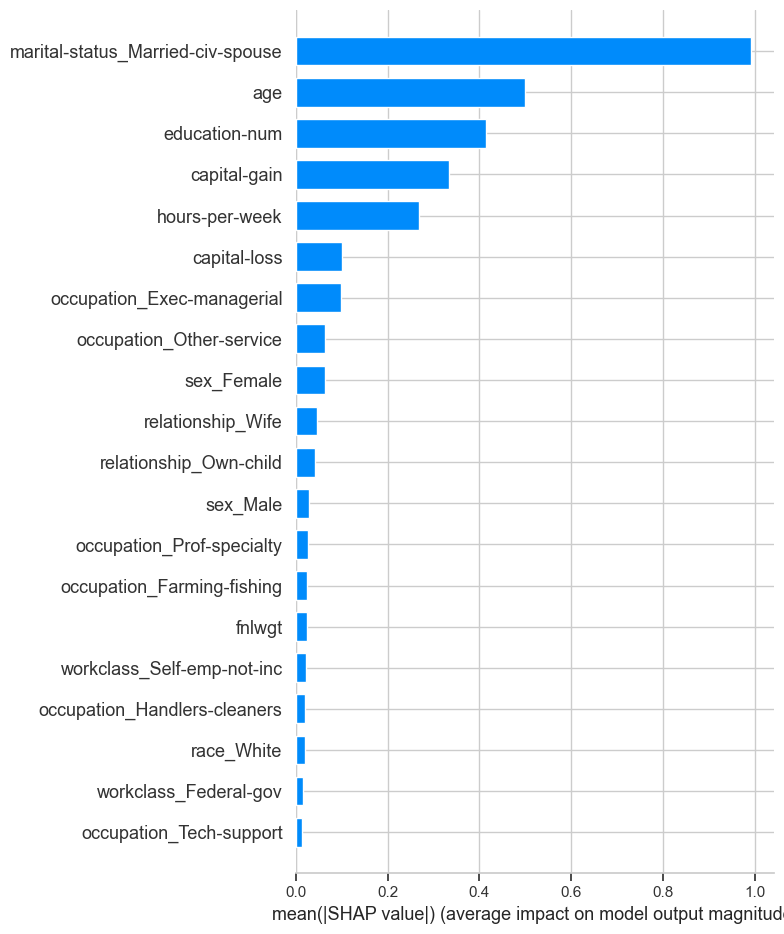

/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_59507/1943416137.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)


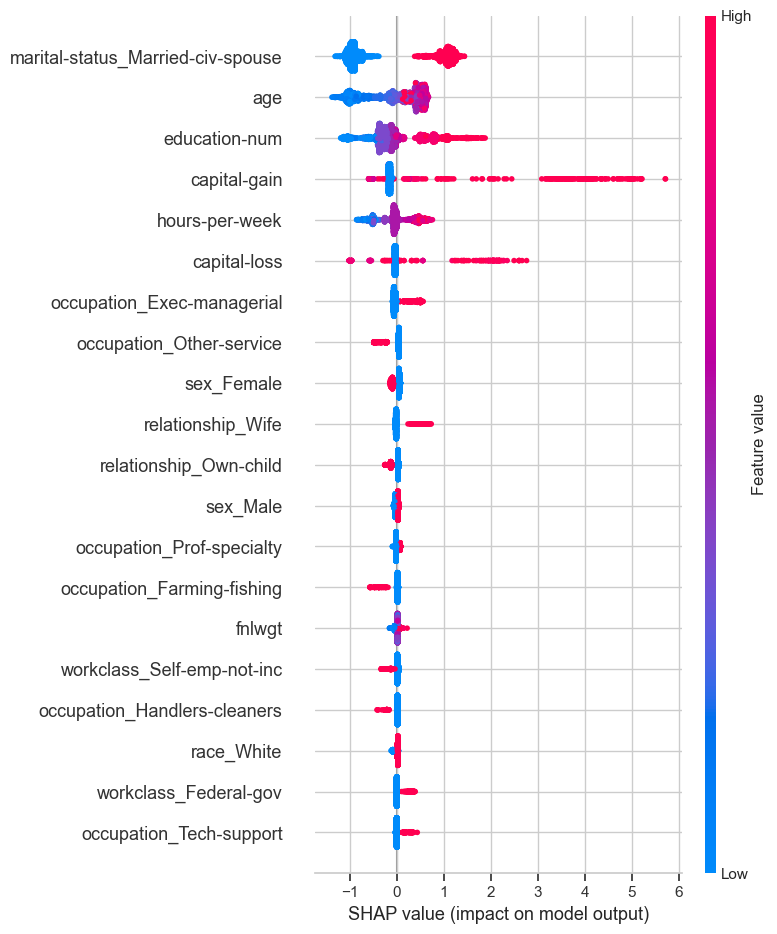

In [7]:
# SHAP global explainability (plan.md: top 5 drivers + proxy discussion in report).

# Install once if needed: %pip install shap
import shap

model_best = best_pipeline.named_steps["classifier"]
X_train_prepared = best_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_prepared = best_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = list(all_feature_names)

# Subsample test rows for faster plots while keeping estimates stable
_shap_rng = np.random.RandomState(RANDOM_STATE)
_max = min(4000, X_test_prepared.shape[0])
_shap_idx = _shap_rng.choice(X_test_prepared.shape[0], size=_max, replace=False)
X_shap = X_test_prepared[_shap_idx]

try:
    explainer = shap.TreeExplainer(model_best)
    shap_values = explainer.shap_values(X_shap)
except Exception as e_tree:
    print("TreeExplainer failed, falling back to KernelExplainer:\n", e_tree)
    bg_n = min(300, len(X_train_prepared))
    bg = X_train_prepared[_shap_rng.choice(len(X_train_prepared), size=bg_n, replace=False)]
    explainer = shap.KernelExplainer(model_best.predict_proba, bg)
    shap_values = explainer.shap_values(X_shap, nsamples=50)

# Binary classifiers sometimes return a list [class0, class1] — use positive class
if isinstance(shap_values, list):
    shap_values = np.asarray(shap_values[1])
else:
    shap_values = np.asarray(shap_values)

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(-mean_abs)
top5 = pd.DataFrame(
    {"feature": [feature_names[i] for i in order[:5]], "mean_abs_shap": mean_abs[order[:5]]}
)
print("Top 5 global drivers (mean |SHAP| on subsample) — cite in report:")
display(top5)

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
import matplotlib.pyplot as plt

plt.tight_layout()
plt.savefig(FIG_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Recourse spot-check (plan.md): one unfavorable prediction (predicted <=50K) and local drivers.
# GDPR Art. 22 framing (human review, meaningful information about logic) belongs in the PDF report.

X_train_prepared = best_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_prepared = best_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = list(all_feature_names)

y_bin = _as_binary_pred(y_pred_best)
proba = np.asarray(y_pred_proba_best, dtype=float)
neg = y_bin == 0
if not neg.any():
    raise RuntimeError("No predicted <=50K on test set — cannot pick a recourse example.")
recourse_idx = int(np.where(neg)[0][np.argmax(proba[neg])])

row = X_test.iloc[recourse_idx]
print("Unfavorable case (borderline): test position", recourse_idx)
print("True income label:", y_test.iloc[recourse_idx], "| Model P(>50K):", float(proba[recourse_idx]))
display(row.to_frame("value"))

# Local SHAP for this row (TreeExplainer when supported; else KernelExplainer like the global cell)
x_row = X_test_prepared[recourse_idx : recourse_idx + 1]
try:
    ex_local = shap.TreeExplainer(model_best)
    sv_row = ex_local.shap_values(x_row)
except Exception:
    bg_n = min(200, len(X_train_prepared))
    _rs = np.random.RandomState(RANDOM_STATE)
    bg = X_train_prepared[_rs.choice(len(X_train_prepared), size=bg_n, replace=False)]
    ex_local = shap.KernelExplainer(model_best.predict_proba, bg)
    sv_row = ex_local.shap_values(x_row, nsamples=100)
if isinstance(sv_row, list):
    sv_row = np.asarray(sv_row[1])
else:
    sv_row = np.asarray(sv_row)
sv_flat = sv_row.ravel()
rank = np.argsort(-np.abs(sv_flat))[:12]
print("Largest |SHAP| for this individual — use for actionable-recourse discussion:")
display(pd.DataFrame({"feature": [feature_names[i] for i in rank], "shap": sv_flat[rank]}))

print(
    "\nIllustrative levers on raw inputs (not a certified counterfactual; discuss ethics of each in report):"
)
print(
    f"  education-num={row['education-num']}, hours-per-week={row['hours-per-week']}, "
    f"age={row['age']}, occupation={row['occupation']}"
)

Unfavorable case (borderline): test position 12401
True income label: >50K | Model P(>50K): 0.49958618927816556


,value
age,52
workclass,Private
fnlwgt,142757
education,Some-college
education-num,10
marital-status,Married-civ-spouse
occupation,Prof-specialty
relationship,Husband
race,Black
sex,Male


Largest |SHAP| for this individual — use for actionable-recourse discussion:


,feature,shap
0,marital-status_Married-civ-spouse,1.104842
1,age,0.582566
2,hours-per-week,0.465538
3,capital-gain,-0.170354
4,race_White,-0.080449
5,occupation_Exec-managerial,-0.077543
6,education-num,-0.062090
7,occupation_Prof-specialty,0.055863
8,capital-loss,-0.045697
9,sex_Female,0.042271



Illustrative levers on raw inputs (not a certified counterfactual; discuss ethics of each in report):
  education-num=10, hours-per-week=56, age=52, occupation=Prof-specialty


In [9]:
# Optional: LIME local explanation (plan.md allows SHAP or LIME). Complements the recourse cell above.
# %pip install lime
try:
    import lime.lime_tabular
except ImportError:
    print("Skipping LIME: install with `pip install lime` (see requirements.txt).")
else:
    X_train_prepared = best_pipeline.named_steps["preprocessor"].transform(X_train)
    X_test_prepared = best_pipeline.named_steps["preprocessor"].transform(X_test)
    lime_feature_names = list(all_feature_names)

    # One-hot columns are named e.g. native-country_Cambodia; infer categoricals from names.
    _numeric = set(numeric_features)
    lime_categorical_idx = [i for i, name in enumerate(lime_feature_names) if name not in _numeric]

    def predict_proba_lime(x):
        return best_pipeline.named_steps["classifier"].predict_proba(x)

    _bg_n = min(3000, len(X_train_prepared))
    _bg_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_prepared), size=_bg_n, replace=False)
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_prepared[_bg_idx],
        feature_names=lime_feature_names,
        class_names=["<=50K", ">50K"],
        mode="classification",
        categorical_features=lime_categorical_idx,
    )

    try:
        _sample_idx = recourse_idx
    except NameError:
        _sample_idx = 0
    lime_exp = lime_explainer.explain_instance(
        np.asarray(X_test_prepared[_sample_idx], dtype=float),
        predict_proba_lime,
        num_features=10,
    )
    from IPython.display import display, HTML

    display(HTML(lime_exp.as_html()))


---
## Phase 3 — Regulatory and policy mapping

Legal analysis, citations, and **full prose** for the compliance table belong in the **PDF**. The next cell builds a **structured gap table**; `audit_finding` text is **evidence from this notebook run** — **paraphrase and expand in your own words** for the report (course AI policy).

Minimum **10 rows** mapping Phase 2 findings to regulations (compliant / non-compliant / gray area).


In [10]:
# Compliance gap table — audit_finding lines use computed Phase 2 values (fairness_sex, fairness_race, top5, recourse).

_fs, _fr = fairness_sex, fairness_race
_top_list = top5["feature"].astype(str).tolist()
_top3_str = ", ".join(_top_list[:3])
_top5_str = ", ".join(_top_list[:5])
_p_rec = float(proba[recourse_idx])

gap_table = pd.DataFrame(
    [
        {
            "audit_finding": (
                f"Sex: P(predicted >50K) {_fs['g0']} {_fs['p_pred_0']:.1%}, {_fs['g1']} {_fs['p_pred_1']:.1%}; "
                f"abs. gap {_fs['dp_gap']:.1%} (demographic parity). TPR gap {_fs['tpr_gap']:.1%}; "
                f"precision (among predicted >50K) gap {_fs['ppv_gap']:.1%}."
            ),
            "regulation": "Title VII, Civil Rights Act of 1964",
            "article_or_section": "Section 703(a)",
            "status": "gray",
            "notes": "Disparate treatment / impact risk; document business necessity if deployed.",
        },
        {
            "audit_finding": (
                f"Race (White vs Non-White): P(predicted >50K) {_fr['g0']} {_fr['p_pred_0']:.1%}, {_fr['g1']} {_fr['p_pred_1']:.1%}; "
                f"abs. gap {_fr['dp_gap']:.1%}; TPR gap {_fr['tpr_gap']:.1%}; precision gap {_fr['ppv_gap']:.1%}."
            ),
            "regulation": "EEOC Uniform Guidelines on Employee Selection Procedures",
            "article_or_section": "Section 4 (adverse impact)",
            "status": "gray",
            "notes": "Monitor selection rates vs. 4/5 rule; justify or mitigate.",
        },
        {
            "audit_finding": f"Global SHAP (mean |SHAP|) top features: {_top5_str}. Review encoded fields for proxy effects.",
            "regulation": "State / local EEO; EU AI Act (high-risk AI transparency)",
            "article_or_section": "Varies by jurisdiction",
            "status": "gray",
            "notes": "High-impact features (e.g. marital, occupation) may correlate with protected classes.",
        },
        {
            "audit_finding": f"Strongest sensitivities in this run: {_top3_str} — assess socioeconomic proxy risk.",
            "regulation": "Fair Chance / state hiring laws (where applicable)",
            "article_or_section": "Varies",
            "status": "gray",
            "notes": "Legitimate predictors can still skew outcomes; document monitoring.",
        },
        {
            "audit_finding": "Training pipeline keeps `sex` and `race` as model inputs (encoded); audit documents indirect effects.",
            "regulation": "GDPR Art. 9; US state privacy laws",
            "article_or_section": "Sensitive / special-category data",
            "status": "gray",
            "notes": "If deployed on EU data subjects, lawful basis and DPIA; minimize use where possible.",
        },
        {
            "audit_finding": "Notebook documents data source, split, metrics, SHAP/LIME hooks for transparency.",
            "regulation": "EU AI Act",
            "article_or_section": "Art. 52 (transparency for certain AI)",
            "status": "compliant",
            "notes": "R&D artifact; production would need user-facing disclosures.",
        },
        {
            "audit_finding": (
                f"Recourse example: borderline unfavorable prediction, P(>50K)={_p_rec:.4f}; local SHAP shows limited levers."
            ),
            "regulation": "GDPR Art. 15/22; CCPA/CPRA; NYC Local Law 144",
            "article_or_section": "Explainability / automated decision-making",
            "status": "non-compliant",
            "notes": "No productized appeal path or certified counterfactuals in this audit.",
        },
        {
            "audit_finding": "No fairness constraints, reweighting, or post-processing applied in this baseline.",
            "regulation": "EEOC guidance; EU AI Act (risk management)",
            "article_or_section": "Bias mitigation expectations",
            "status": "non-compliant",
            "notes": "Plan mitigation before deployment (calibration, thresholds, constrained learning, etc.).",
        },
        {
            "audit_finding": "No human-in-the-loop review or contestation workflow for scores.",
            "regulation": "GDPR Art. 22",
            "article_or_section": "Automated individual decision-making",
            "status": "non-compliant",
            "notes": "Add meaningful human review where Art. 22 applies.",
        },
        {
            "audit_finding": "No live monitoring, drift detection, or scheduled retrain policy in this artifact.",
            "regulation": "EU AI Act Art. 61; NIST AI RMF (Monitor)",
            "article_or_section": "Post-market monitoring / Govern",
            "status": "non-compliant",
            "notes": "Define KPIs, logging, and periodic fairness audits for production.",
        },
    ]
)
gap_table


,audit_finding,regulation,article_or_section,status,notes
0,"Sex: P(predicted >50K) Male 23.4%, Female 7.2%...","Title VII, Civil Rights Act of 1964",Section 703(a),gray,Disparate treatment / impact risk; document bu...
1,Race (White vs Non-White): P(predicted >50K) W...,EEOC Uniform Guidelines on Employee Selection ...,Section 4 (adverse impact),gray,Monitor selection rates vs. 4/5 rule; justify ...
2,Global SHAP (mean |SHAP|) top features: marita...,State / local EEO; EU AI Act (high-risk AI tra...,Varies by jurisdiction,gray,"High-impact features (e.g. marital, occupation..."
3,Strongest sensitivities in this run: marital-s...,Fair Chance / state hiring laws (where applica...,Varies,gray,Legitimate predictors can still skew outcomes;...
4,Training pipeline keeps `sex` and `race` as mo...,GDPR Art. 9; US state privacy laws,Sensitive / special-category data,gray,"If deployed on EU data subjects, lawful basis ..."
5,"Notebook documents data source, split, metrics...",EU AI Act,Art. 52 (transparency for certain AI),compliant,R&D artifact; production would need user-facin...
6,Recourse example: borderline unfavorable predi...,GDPR Art. 15/22; CCPA/CPRA; NYC Local Law 144,Explainability / automated decision-making,non-compliant,No productized appeal path or certified counte...
7,"No fairness constraints, reweighting, or post-...",EEOC guidance; EU AI Act (risk management),Bias mitigation expectations,non-compliant,Plan mitigation before deployment (calibration...
8,No human-in-the-loop review or contestation wo...,GDPR Art. 22,Automated individual decision-making,non-compliant,Add meaningful human review where Art. 22 appl...
9,"No live monitoring, drift detection, or schedu...",EU AI Act Art. 61; NIST AI RMF (Monitor),Post-market monitoring / Govern,non-compliant,"Define KPIs, logging, and periodic fairness au..."


---
## Phase 4 — Governance

- **Pre-deployment checklist** (≥10 items) — expand in the **report**; the code cell lists audit-specific reminders tied to this run.
- **Stakeholder disclosure** (≤1 page) — write in report.


**Pre-deployment Fairness & Governance Checklist**

1. Document baseline sex/race fairness gaps (demographic parity, TPR, precision) and targets pre-deployment.
2. Log and monitor P(predicted >50K) and error rates by sex and White vs Non-White (or finer race) per EEOC / internal policy.
3. Review SHAP top drivers for proxy variables (marital status, occupation, native-country encodings).
4. Require human review for scores in a defined band (e.g. near 0.5) before adverse hiring actions.
5. Publish data lineage: UCI Adult, canonical train/test via `dataset_split`, and `scripts/build_adult_csv.py`.
6. Map controls to NIST AI RMF Govern/Map/Measure/Manage before production sign-off.
7. Implement bias mitigation (reweighting, thresholding, post-processing, or fairness constraints) if gaps exceed policy.
8. Provide applicant-facing explanation and appeal consistent with GDPR Art. 22 / CCPA / NYC LL 144 where applicable.
9. Version models; retain artifacts so PDF and notebook numbers can be reproduced.
10. Schedule periodic retraining and drift checks; alert on fairness metric regression.
11. Legal review of Title VII, EEOC guidelines, GDPR/EU AI Act, and state/local hiring rules for the deployment context.
"""